In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Carga de datos del archivo correlacion_csv de la clave F

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/AsaelP25/Parcial4_Humberto_Parada_2510772022/refs/heads/main/Archivos/clave_F_correlacion.csv')
df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,F-C0001,18,1184,6,63.55,7.05,1,2,20.42,344.76
1,F-C0002,32,1023,8,60.06,7.88,2,7,12.99,475.57
2,F-C0003,46,1231,9,61.11,7.22,1,5,23.16,554.42
3,F-C0004,48,783,4,37.37,5.69,4,4,26.98,233.89
4,F-C0005,31,1187,7,65.26,3.50,8,7,28.48,386.42


In [3]:
df.shape

(246, 10)

El dataset de correlación contiene información de clientes. Entre las variables se encuentran edad, ingresos mensuales, frecuencia de compra, ticket promedio, satisfacción, reclamos, uso de aplicación, tiempo de respuesta y consumo total.

Verificar valores nulos, duplicados y tipos de datos.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          246 non-null    object 
 1   edad                246 non-null    int64  
 2   ingresos_mensuales  246 non-null    int64  
 3   frecuencia_compra   246 non-null    int64  
 4   ticket_promedio     245 non-null    float64
 5   satisfaccion        245 non-null    float64
 6   reclamos            246 non-null    int64  
 7   uso_app             246 non-null    int64  
 8   tiempo_respuesta    245 non-null    float64
 9   consumo_total       246 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 19.3+ KB


In [5]:
df.isnull().sum()

,0
cliente_id,0
edad,0
ingresos_mensuales,0
frecuencia_compra,0
ticket_promedio,1
satisfaccion,1
reclamos,0
uso_app,0
tiempo_respuesta,1
consumo_total,0


In [6]:
df.duplicated().sum()

np.int64(1)

Limpiar datos

In [9]:
# Rellenar valores nulos en columnas numéricas usando la mediana
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns

for columna in columnas_numericas:
    df[columna] = df[columna].fillna(df[columna].median())

# Eliminar registros duplicados
df = df.drop_duplicates()

In [10]:
df.isnull().sum()

,0
cliente_id,0
edad,0
ingresos_mensuales,0
frecuencia_compra,0
ticket_promedio,0
satisfaccion,0
reclamos,0
uso_app,0
tiempo_respuesta,0
consumo_total,0


In [11]:
df.duplicated().sum()

np.int64(0)

Durante la revisión del dataset se identificaron valores nulos en columnas numéricas y un registro duplicado.

Los valores nulos fueron reemplazados usando la mediana de cada columna, ya que esta medida reduce el efecto de posibles valores extremos. Además, se eliminó el registro duplicado para evitar que un mismo cliente o registro afectara dos veces el análisis.

Después de la limpieza, el dataset quedó sin valores nulos ni registros duplicados.

Identificar variables numéricas

In [12]:
variables_numericas = df.select_dtypes(include=["int64", "float64"])

variables_numericas.head()

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,18,1184,6,63.55,7.05,1,2,20.42,344.76
1,32,1023,8,60.06,7.88,2,7,12.99,475.57
2,46,1231,9,61.11,7.22,1,5,23.16,554.42
3,48,783,4,37.37,5.69,4,4,26.98,233.89
4,31,1187,7,65.26,3.50,8,7,28.48,386.42


In [13]:
variables_numericas.columns

Index(['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio',
       'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta',
       'consumo_total'],
      dtype='object')

Para el análisis de correlación se seleccionaron únicamente las variables numéricas, ya que la correlación mide la relación estadística entre variables cuantitativas.

Revisar valores atípicos

In [14]:
variables_numericas.describe()

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000
mean,38.771429,1119.440816,7.902041,66.285673,7.527551,1.538776,5.636735,21.045347,524.958122
std,10.233583,263.971282,3.294089,15.390433,1.339711,1.751910,2.071142,6.727660,223.539399
min,18.000000,484.000000,2.000000,27.130000,3.020000,0.000000,0.000000,5.000000,145.720000
25%,31.000000,926.000000,6.000000,56.500000,6.790000,0.000000,4.000000,16.600000,377.180000
50%,39.000000,1117.000000,8.000000,66.020000,7.750000,1.000000,6.000000,20.550000,514.740000
75%,46.000000,1298.000000,9.000000,75.950000,8.510000,2.000000,7.000000,25.470000,627.840000
max,62.000000,1838.000000,32.000000,114.020000,10.000000,9.000000,10.000000,43.500000,2026.660000


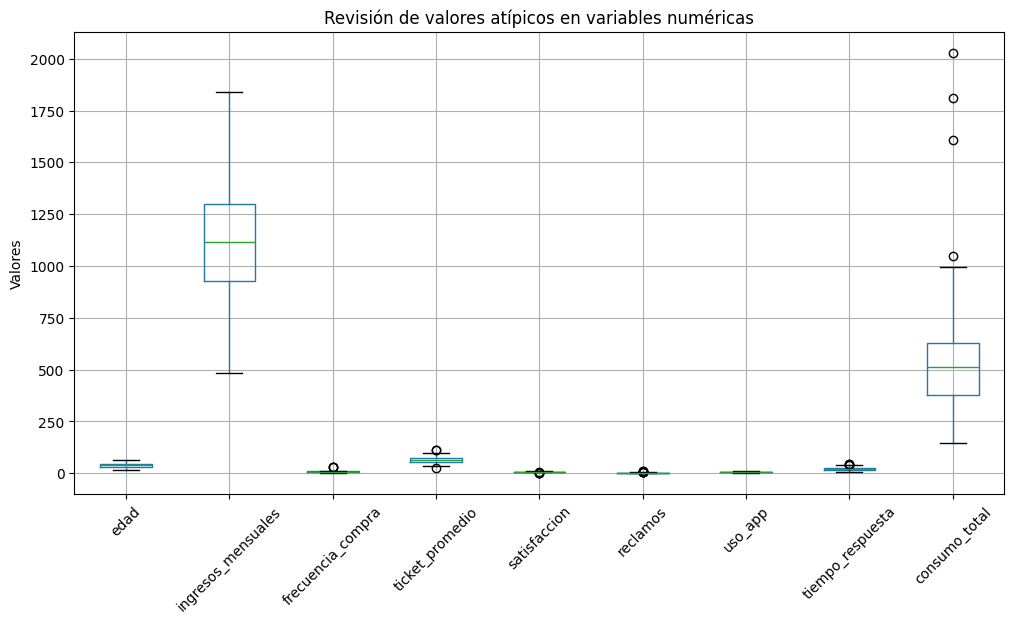

In [18]:
plt.figure(figsize=(12, 6))
variables_numericas.boxplot(rot=45)
plt.title("Revisión de valores atípicos en variables numéricas")
plt.ylabel("Valores")
plt.show()


Se utilizó estadística descriptiva y un diagrama de caja para revisar posibles valores atípicos. Esta revisión permite identificar datos que se alejan demasiado del comportamiento general de las variables.

Calcular la matriz de correlación

In [19]:
matriz_correlacion = variables_numericas.corr()

matriz_correlacion

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,0.074459,0.073616,0.144897,-0.017259,0.046902,0.060069,0.015043,0.098105
ingresos_mensuales,0.074459,1.000000,0.068764,0.659950,-0.056723,0.004270,-0.040493,0.175383,0.321616
frecuencia_compra,0.073616,0.068764,1.000000,0.172631,0.124332,-0.068936,0.400843,-0.083815,0.897235
ticket_promedio,0.144897,0.659950,0.172631,1.000000,-0.028270,-0.010720,-0.001086,0.078764,0.527329
satisfaccion,-0.017259,-0.056723,0.124332,-0.028270,1.000000,-0.829007,0.240079,-0.625284,0.179001
reclamos,0.046902,0.004270,-0.068936,-0.010720,-0.829007,1.000000,-0.020386,0.620212,-0.141421
uso_app,0.060069,-0.040493,0.400843,-0.001086,0.240079,-0.020386,1.000000,-0.213350,0.394528
tiempo_respuesta,0.015043,0.175383,-0.083815,0.078764,-0.625284,0.620212,-0.213350,1.000000,-0.114891
consumo_total,0.098105,0.321616,0.897235,0.527329,0.179001,-0.141421,0.394528,-0.114891,1.000000


Crear mapa de calor

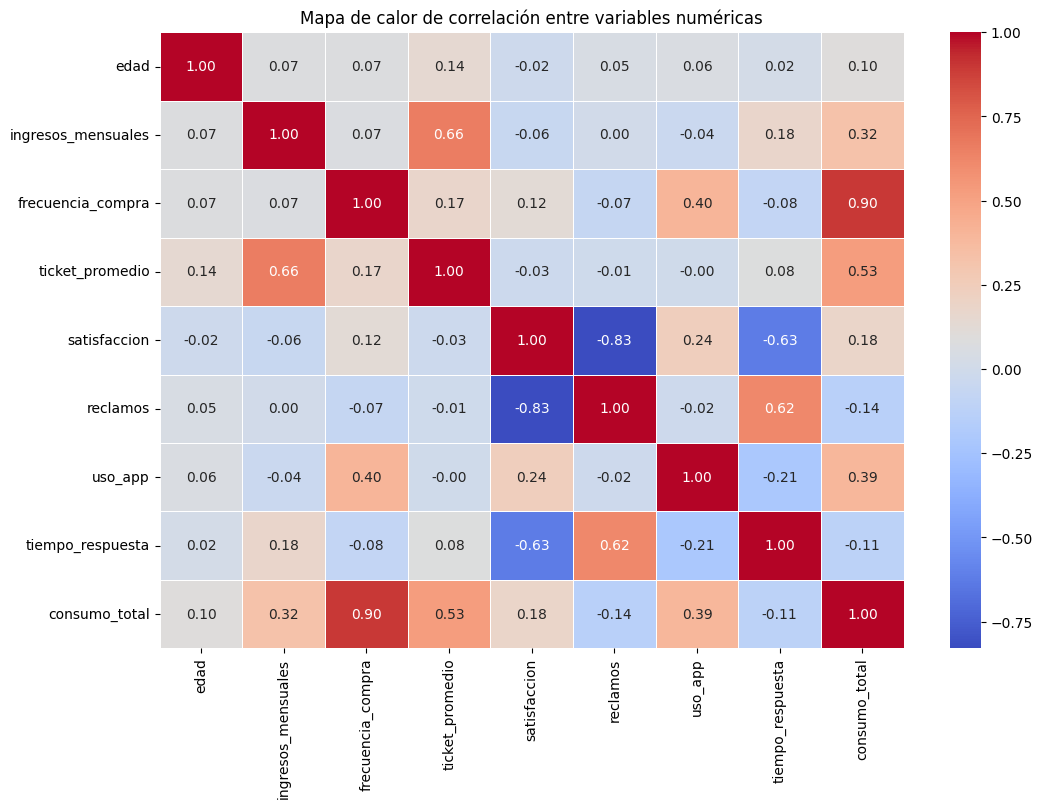

In [21]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa de calor de correlación entre variables numéricas")
plt.show()

El mapa de calor permite visualizar la intensidad y dirección de las relaciones entre variables. Los valores cercanos a 1 indican correlación positiva fuerte, los valores cercanos a -1 indican correlación negativa fuerte y los valores cercanos a 0 indican poca o ninguna relación lineal.

Identificar correlaciones positivas más importantes

In [22]:
correlaciones = matriz_correlacion.unstack().reset_index()
correlaciones.columns = ["Variable 1", "Variable 2", "Correlación"]

# Eliminar correlaciones de una variable consigo misma
correlaciones = correlaciones[correlaciones["Variable 1"] != correlaciones["Variable 2"]]

# Evitar pares duplicados
correlaciones["Par ordenado"] = correlaciones.apply(
    lambda fila: tuple(sorted([fila["Variable 1"], fila["Variable 2"]])),
    axis=1
)

correlaciones = correlaciones.drop_duplicates("Par ordenado")

correlaciones_positivas = correlaciones.sort_values(
    by="Correlación",
    ascending=False
)

correlaciones_positivas.head(10)

,Variable 1,Variable 2,Correlación,Par ordenado
26,frecuencia_compra,consumo_total,0.897235,"(consumo_total, frecuencia_compra)"
12,ingresos_mensuales,ticket_promedio,0.659950,"(ingresos_mensuales, ticket_promedio)"
52,reclamos,tiempo_respuesta,0.620212,"(reclamos, tiempo_respuesta)"
35,ticket_promedio,consumo_total,0.527329,"(consumo_total, ticket_promedio)"
24,frecuencia_compra,uso_app,0.400843,"(frecuencia_compra, uso_app)"
62,uso_app,consumo_total,0.394528,"(consumo_total, uso_app)"
17,ingresos_mensuales,consumo_total,0.321616,"(consumo_total, ingresos_mensuales)"
42,satisfaccion,uso_app,0.240079,"(satisfaccion, uso_app)"
44,satisfaccion,consumo_total,0.179001,"(consumo_total, satisfaccion)"
16,ingresos_mensuales,tiempo_respuesta,0.175383,"(ingresos_mensuales, tiempo_respuesta)"


Identificar correlaciones negativas más importantes

In [23]:
correlaciones_negativas = correlaciones.sort_values(
    by="Correlación",
    ascending=True
)

correlaciones_negativas.head(10)

,Variable 1,Variable 2,Correlación,Par ordenado
41,satisfaccion,reclamos,-0.829007,"(reclamos, satisfaccion)"
43,satisfaccion,tiempo_respuesta,-0.625284,"(satisfaccion, tiempo_respuesta)"
61,uso_app,tiempo_respuesta,-0.213350,"(tiempo_respuesta, uso_app)"
53,reclamos,consumo_total,-0.141421,"(consumo_total, reclamos)"
71,tiempo_respuesta,consumo_total,-0.114891,"(consumo_total, tiempo_respuesta)"
25,frecuencia_compra,tiempo_respuesta,-0.083815,"(frecuencia_compra, tiempo_respuesta)"
23,frecuencia_compra,reclamos,-0.068936,"(frecuencia_compra, reclamos)"
13,ingresos_mensuales,satisfaccion,-0.056723,"(ingresos_mensuales, satisfaccion)"
15,ingresos_mensuales,uso_app,-0.040493,"(ingresos_mensuales, uso_app)"
31,ticket_promedio,satisfaccion,-0.028270,"(satisfaccion, ticket_promedio)"
